In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import pickle

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current folder:
d:\current documents\Desktop\Final project

Files and folders here:
['archive.zip', 'association_rules.csv', 'Assosiation_rule.ipynb', 'cnn_model.h5', 'CNN_project.ipynb', 'dirty_v3_path.csv', 'drugLibTest_raw.tsv', 'drugLibTrain_raw.tsv', 'final project explanation.txt', 'Final_project.ipynb', 'HealthAI.docx.pdf', 'hospital.csv', 'lstm_project.ipynb', 'myenv', 'patient_segmented_output.csv', 'physio_net', 'Radiography', 'Regression_model.ipynb', 'Sentiment.ipynb']


In [4]:
import os

for file in os.listdir():
    if "drugLib" in file or "druglib" in file:
        print(repr(file))

'drugLibTest_raw.tsv'
'drugLibTrain_raw.tsv'


In [5]:
import pandas as pd

train_path = "drugLibTrain_raw.tsv"
test_path = "drugLibTest_raw.tsv"

train_df = pd.read_csv(
    train_path,
    sep="\t",
    quotechar='"',
    engine="python"
)

test_df = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python"
)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)
print("Training columns:")
print(train_df.columns.tolist())

print("\nFirst 5 rows:")
display(train_df.head())

Training dataset shape: (3107, 9)
Testing dataset shape: (1036, 9)
Training columns:
['Unnamed: 0', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']

First 5 rows:


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [6]:
print(train_df.shape)
print(test_df.shape)
print(train_df.columns.tolist())

(3107, 9)
(1036, 9)
['Unnamed: 0', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']


In [7]:
print("Training dataset information:")
train_df.info()
print("\nTesting dataset information:")
test_df.info()

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB

Testing dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         1036 non-null   int64 
 1   urlDrugName  

In [8]:
print("TRAINING DATA - MISSING VALUES")
print(train_df.isnull().sum())

print("\nTESTING DATA - MISSING VALUES")
print(test_df.isnull().sum())

TRAINING DATA - MISSING VALUES
Unnamed: 0            0
urlDrugName           0
rating                0
effectiveness         0
sideEffects           0
condition             1
benefitsReview       18
sideEffectsReview    75
commentsReview       12
dtype: int64

TESTING DATA - MISSING VALUES
Unnamed: 0            0
urlDrugName           0
rating                0
effectiveness         0
sideEffects           0
condition             0
benefitsReview        5
sideEffectsReview    23
commentsReview        1
dtype: int64


In [9]:
#hadle missing values
text_columns = [
    "benefitsReview",
    "sideEffectsReview",
    "commentsReview"
]

for col in text_columns:
    train_df[col] = train_df[col].fillna("")
    test_df[col] = test_df[col].fillna("")
    train_df["condition"] = train_df["condition"].fillna("Unknown")
    test_df["condition"] = test_df["condition"].fillna("Unknown")

In [10]:
print("Training duplicate rows:", train_df.duplicated().sum())
print("Testing duplicate rows:", test_df.duplicated().sum())

Training duplicate rows: 0
Testing duplicate rows: 0


In [11]:
print("Rating distribution in training data:")
print(train_df["rating"].value_counts().sort_index())

Rating distribution in training data:
rating
1     305
2     103
3     146
4     107
5     159
6     157
7     350
8     558
9     480
10    742
Name: count, dtype: int64


In [12]:
print("TRAINING DATA - MISSING VALUES")
print(train_df.isnull().sum())

print("\nTESTING DATA - MISSING VALUES")
print(test_df.isnull().sum())

TRAINING DATA - MISSING VALUES
Unnamed: 0           0
urlDrugName          0
rating               0
effectiveness        0
sideEffects          0
condition            0
benefitsReview       0
sideEffectsReview    0
commentsReview       0
dtype: int64

TESTING DATA - MISSING VALUES
Unnamed: 0           0
urlDrugName          0
rating               0
effectiveness        0
sideEffects          0
condition            0
benefitsReview       0
sideEffectsReview    0
commentsReview       0
dtype: int64


In [13]:
#remove unncessary cpolumn
train_df = train_df.drop(columns=["Unnamed: 0"])
test_df = test_df.drop(columns=["Unnamed: 0"])

In [14]:
#combine the txt
train_df["review_text"] = (
    train_df["benefitsReview"].astype(str) + " " +
    train_df["sideEffectsReview"].astype(str) + " " +
    train_df["commentsReview"].astype(str)
)

test_df["review_text"] = (
    test_df["benefitsReview"].astype(str) + " " +
    test_df["sideEffectsReview"].astype(str) + " " +
    test_df["commentsReview"].astype(str)
)

In [15]:
display(
    train_df[
        [
            "benefitsReview",
            "sideEffectsReview",
            "commentsReview",
            "review_text",
            "rating"
        ]
    ].head()
)

,benefitsReview,sideEffectsReview,commentsReview,review_text,rating
0,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",slowed the progression of left ventricular dys...,4
1,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",Although this type of birth control has more c...,1
2,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,I was used to having cramps so badly that they...,10
3,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,The acid reflux went away for a few months aft...,3
4,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,I think that the Lyrica was starting to help w...,2


In [16]:
#calculate review length
train_df["review_length"] = train_df["review_text"].apply(len)
test_df["review_length"] = test_df["review_text"].apply(len)
print(train_df["review_length"].describe())

count    3107.000000
mean      661.253943
std       426.803514
min         2.000000
25%       381.000000
50%       545.000000
75%       814.500000
max      4518.000000
Name: review_length, dtype: float64


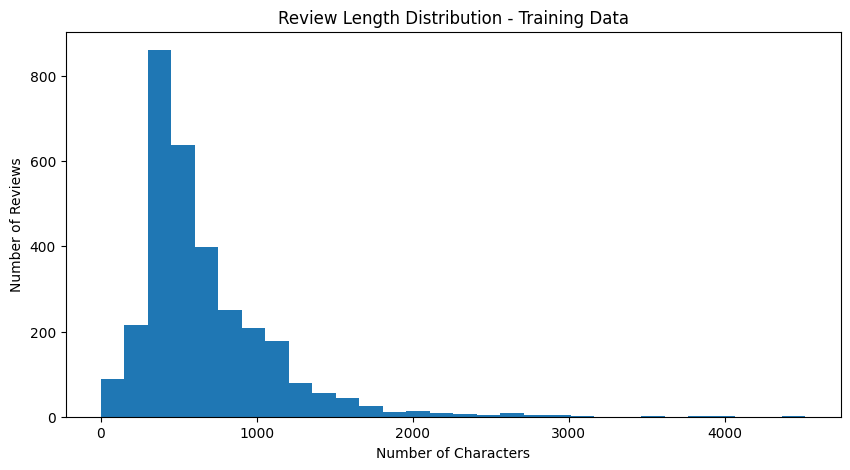

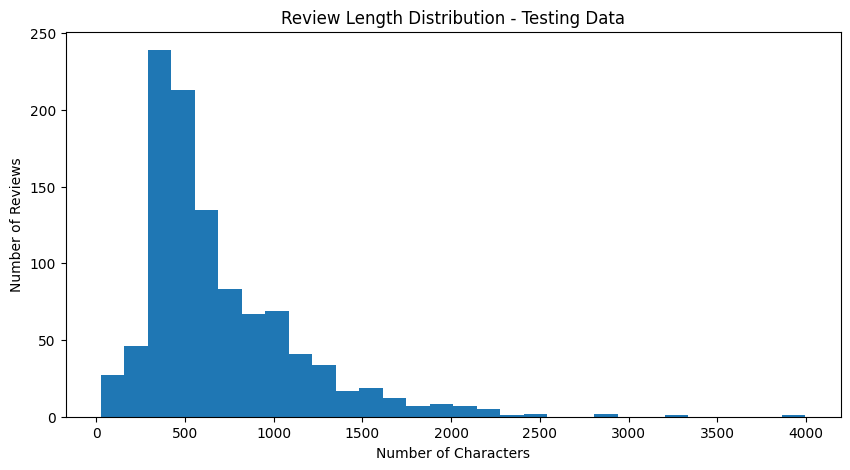

In [17]:
#review length distribution
#training
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["review_length"],
    bins=30
)

plt.title("Review Length Distribution - Training Data")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.show()
#testing
plt.figure(figsize=(10, 5))

plt.hist(
    test_df["review_length"],
    bins=30
)

plt.title("Review Length Distribution - Testing Data")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.show()

Training Word Count
count    3107.000000
mean      117.865787
std        78.163595
min         0.000000
25%        66.000000
50%        96.000000
75%       147.000000
max       873.000000
Name: word_count, dtype: float64

Testing Word Count
count    1036.000000
mean      123.401544
std        80.314641
min         5.000000
25%        68.000000
50%        98.000000
75%       157.000000
max       641.000000
Name: word_count, dtype: float64


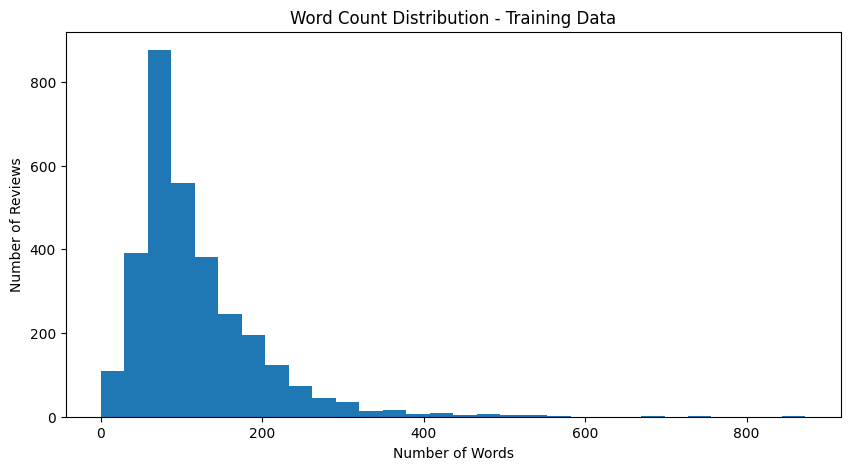

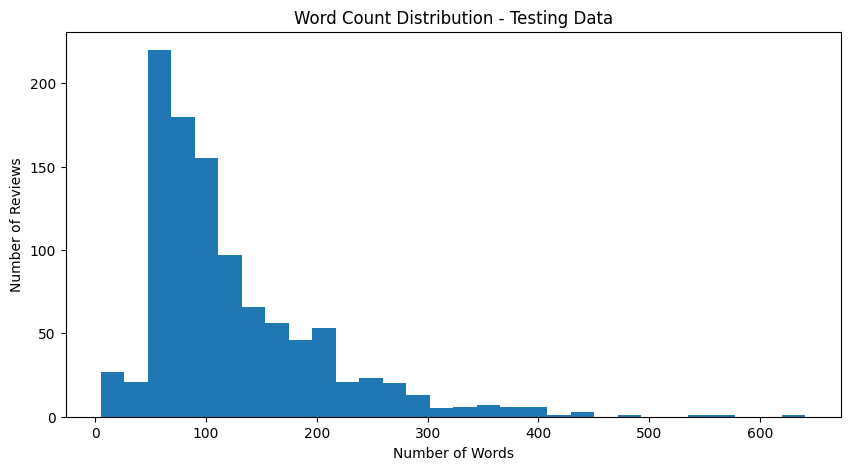

In [18]:
#calculate the word count
train_df["word_count"] = train_df["review_text"].apply(
    lambda x: len(x.split())
)

test_df["word_count"] = test_df["review_text"].apply(
    lambda x: len(x.split())
)
print("Training Word Count")
print(train_df["word_count"].describe())
print("\nTesting Word Count")
print(test_df["word_count"].describe())
#word count distribution
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["word_count"],
    bins=30
)

plt.title("Word Count Distribution - Training Data")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()
#testing
plt.figure(figsize=(10, 5))

plt.hist(
    test_df["word_count"],
    bins=30
)

plt.title("Word Count Distribution - Testing Data")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

rating
1     305
2     103
3     146
4     107
5     159
6     157
7     350
8     558
9     480
10    742
Name: count, dtype: int64


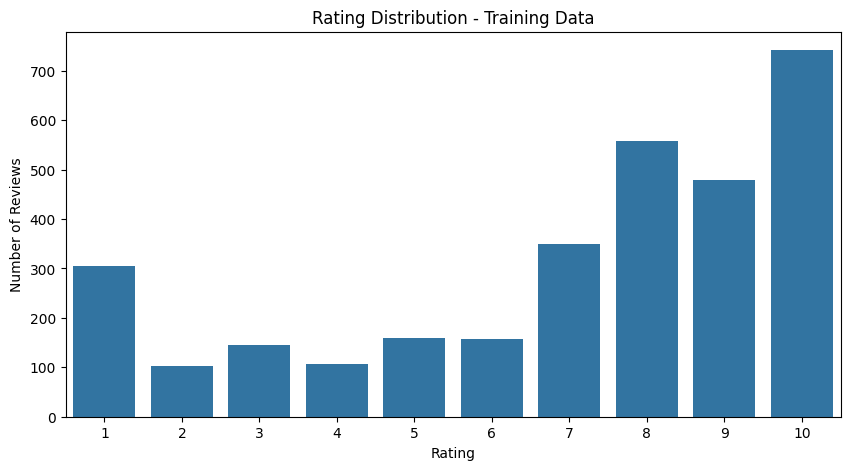

In [29]:
train_rating_counts = train_df["rating"].value_counts().sort_index()

print(train_rating_counts)
#rating distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="rating",
    order=sorted(train_df["rating"].dropna().unique())
)

plt.title("Rating Distribution - Training Data")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

rating
1     115
2      33
3      49
4      44
5      67
6      58
7     121
8     190
9     133
10    226
Name: count, dtype: int64


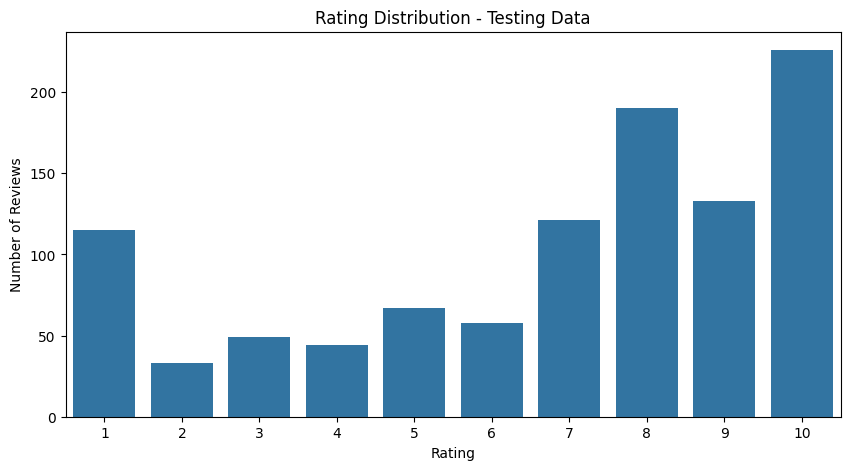

In [28]:
#testing
test_rating_counts = test_df["rating"].value_counts().sort_index()

print(test_rating_counts)
plt.figure(figsize=(10, 5))

sns.countplot(
    data=test_df,
    x="rating",
    order=sorted(test_df["rating"].dropna().unique())
)

plt.title("Rating Distribution - Testing Data")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [19]:
#most common training data
print("Most common training ratings:")
print(train_df["rating"].value_counts().head())
#testing
print("\nMost common testing ratings:")
print(test_df["rating"].value_counts().head())

Most common training ratings:
rating
10    742
8     558
9     480
7     350
1     305
Name: count, dtype: int64

Most common testing ratings:
rating
10    226
8     190
9     133
7     121
1     115
Name: count, dtype: int64


In [20]:
#average review length
print(
    "Average training review length:",
    round(train_df["review_length"].mean(), 2)
)

print(
    "Average testing review length:",
    round(test_df["review_length"].mean(), 2)
)

Average training review length: 661.25
Average testing review length: 691.37


In [21]:
#average word count
print(
    "Average training word count:",
    round(train_df["word_count"].mean(), 2)
)

print(
    "Average testing word count:",
    round(test_df["word_count"].mean(), 2)
)

Average training word count: 117.87
Average testing word count: 123.4


In [22]:
#shortest and longest review
print("Shortest training review:")
print(train_df.loc[
    train_df["word_count"].idxmin(),
    "review_text"
])
print("\nLongest training review:")
print(train_df.loc[
    train_df["word_count"].idxmax(),
    "review_text"
])

Shortest training review:
  

Longest training review:
The effexor worked the first day I took it.  For some time previously, I had felt "paralyzed," or too depressed to get much done.  The day I began taking it, I noticed a difference in that I felt more able to get out of the house, and able to cope with the difficulties of mothering 6 children full-time. As I said, it worked the first day, but continued to work better and better over the next 3 weeks until I worked up to my eventual dose (I started at 37 mg. and worked my way up to 300 mg.). The only side effect I noticed was that if, for some reason, I forgot to take the effexor in the morning, by the evening I felt sort of dizzy in a really weird way. I'm not clear on what is wanted in this section.  I will do my best, and if you wish to email me with a request for specific info, I will be happy to help.  I was seeing a psychiatrist 9 years ago who thought Effexor was worth a try.  I had been on Prozac a few yrs previous, and alth

In [23]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("Training records :", len(train_df))
print("Testing records  :", len(test_df))
print("Total records    :", len(train_df) + len(test_df))

print("\nTraining duplicates:", train_df.duplicated().sum())
print("Testing duplicates :", test_df.duplicated().sum())

print("\nTraining missing values:")
print(train_df.isnull().sum())

print("\nTesting missing values:")
print(test_df.isnull().sum())

print("\nMost common training rating:")
print(train_df["rating"].value_counts().idxmax())

print("\nMost common testing rating:")
print(test_df["rating"].value_counts().idxmax())

print("\nAverage training word count:",
      round(train_df["word_count"].mean(), 2))

print("Average testing word count:",
      round(test_df["word_count"].mean(), 2))

EDA SUMMARY
Training records : 3107
Testing records  : 1036
Total records    : 4143

Training duplicates: 31
Testing duplicates : 4

Training missing values:
urlDrugName          0
rating               0
effectiveness        0
sideEffects          0
condition            0
benefitsReview       0
sideEffectsReview    0
commentsReview       0
review_text          0
review_length        0
word_count           0
dtype: int64

Testing missing values:
urlDrugName          0
rating               0
effectiveness        0
sideEffects          0
condition            0
benefitsReview       0
sideEffectsReview    0
commentsReview       0
review_text          0
review_length        0
word_count           0
dtype: int64

Most common training rating:
10

Most common testing rating:
10

Average training word count: 117.87
Average testing word count: 123.4


In [24]:
#text cleaning
import re

def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()
train_df["clean_text"] = train_df["review_text"].apply(clean_text)
test_df["clean_text"] = test_df["review_text"].apply(clean_text)

In [25]:
for i in range(3):
    print("BEFORE:")
    print(train_df["review_text"].iloc[i])
    
    print("\nAFTER:")
    print(train_df["clean_text"].iloc[i])
    
    print("=" * 80)

BEFORE:
slowed the progression of left ventricular dysfunction into overt heart failure 
alone or with other agents in the managment of hypertension 
mangagement of congestive heart failur cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness monitor blood pressure , weight and asses for resolution of fluid

AFTER:
slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the managment of hypertension mangagement of congestive heart failur cough hypotension proteinuria impotence renal failure angina pectoris tachycardia eosinophilic pneumonitis tastes disturbances anusease anorecia weakness fatigue insominca weakness monitor blood pressure weight and asses for resolution of fluid
BEFORE:
Although this type of birth control has more cons than pros, it did help with my cramps. It's also effectiv

In [26]:
#remove empty review
train_df = train_df[
    train_df["clean_text"].str.strip() != ""
].copy()

test_df = test_df[
    test_df["clean_text"].str.strip() != ""
].copy()
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (3106, 12)
Testing shape: (1036, 12)


In [41]:
def rating_to_sentiment(rating):
    if rating <= 4:
        return "Negative"
    elif rating <= 6:
        return "Neutral"
    else:
        return "Positive"


train_df["sentiment"] = train_df["rating"].apply(rating_to_sentiment)
test_df["sentiment"] = test_df["rating"].apply(rating_to_sentiment)

print(train_df[["rating", "sentiment"]].head(10))

   rating sentiment
0       4  Negative
1       1  Negative
2      10  Positive
3       3  Negative
4       2  Negative
5       1  Negative
6       9  Positive
7      10  Positive
8      10  Positive
9       1  Negative


In [42]:
print("\nPredicted rating distribution:")
print(results["Predicted_Rating"].value_counts().sort_index())
print("\nActual rating distribution:")
print(results["Actual_Rating"].value_counts().sort_index())


Predicted rating distribution:
Predicted_Rating
1      68
2      27
3      38
4      31
5      51
6      45
7     120
8     162
9     214
10    280
Name: count, dtype: int64

Actual rating distribution:
Actual_Rating
1     115
2      33
3      49
4      44
5      67
6      58
7     121
8     190
9     133
10    226
Name: count, dtype: int64


In [43]:
print("Training sentiment distribution:")
print(train_df["sentiment"].value_counts())

print("\nTesting sentiment distribution:")
print(test_df["sentiment"].value_counts())

Training sentiment distribution:
sentiment
Positive    2129
Negative     661
Neutral      316
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
Positive    670
Negative    241
Neutral     125
Name: count, dtype: int64


In [46]:
#prepae x and y
X_train = train_df["clean_text"].astype(str)
X_test = test_df["clean_text"].astype(str)

y_train = train_df["sentiment"]
y_test = test_df["sentiment"]


In [48]:
#convert sentimen to numbers
sentiment_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

y_train_encoded = y_train.map(sentiment_mapping).values
y_test_encoded = y_test.map(sentiment_mapping).values

print("Training labels:", np.unique(y_train_encoded, return_counts=True))
print("Testing labels:", np.unique(y_test_encoded, return_counts=True))
#create newtokenzier
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

vocab_size = min(
    max_words,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size:", vocab_size)

Training labels: (array([0, 1, 2]), array([ 661,  316, 2129]))
Testing labels: (array([0, 1, 2]), array([241, 125, 670]))
Vocabulary size: 10000


In [49]:
#convert txt to squence
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("First training sequence:")
print(X_train_seq[0][:20])

First training sequence:
[1194, 3, 2087, 7, 401, 7309, 1805, 225, 4510, 246, 2088, 806, 34, 15, 83, 3410, 11, 3, 7310, 7]


In [50]:
max_length = 255
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)

X_train shape: (3106, 255)
X_test shape: (1036, 255)


In [52]:
# check class imbalance
from collections import Counter

print("Training classes:")
print(Counter(y_train_encoded))

print("\nTesting classes:")
print(Counter(y_test_encoded))
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_encoded)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")
print(class_weights)

Training classes:
Counter({np.int64(2): 2129, np.int64(0): 661, np.int64(1): 316})

Testing classes:
Counter({np.int64(2): 670, np.int64(0): 241, np.int64(1): 125})
Class weights:
{np.int64(0): np.float64(1.5663136661623802), np.int64(1): np.float64(3.2763713080168775), np.int64(2): np.float64(0.48630029747925474)}


In [68]:
#buildthe new BiLSTM
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.regularizers import l2

model = Sequential([
    
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),

    Bidirectional(
        LSTM(32)
    ),

    Dropout(0.6),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.005)
    ),

    Dropout(0.5),

    Dense(
        3,
        activation="softmax"
    )
])

model.summary()
#COMPILE THE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)


c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.4163 - loss: 1.2545 - val_accuracy: 0.6624 - val_loss: 1.2220
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.4928 - loss: 1.1936 - val_accuracy: 0.6527 - val_loss: 1.1684
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.4622 - loss: 1.1494 - val_accuracy: 0.6688 - val_loss: 1.1276
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.5898 - loss: 1.0794 - val_accuracy: 0.6640 - val_loss: 1.0670
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.6715 - loss: 0.9572 - val_accuracy: 0.6415 - val_loss: 0.9960
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.6739 - loss: 0.7618 - val_accuracy: 0.3006 - val_loss: 1.1274
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.7234 - loss: 0.6326 - val_accuracy: 0.5080 - val_loss: 1.1433


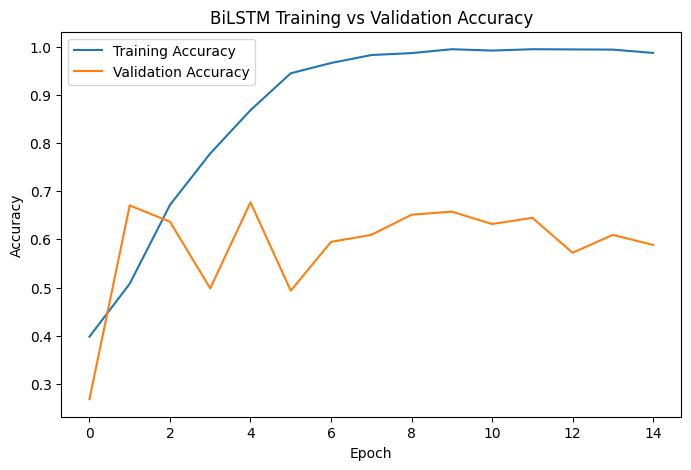

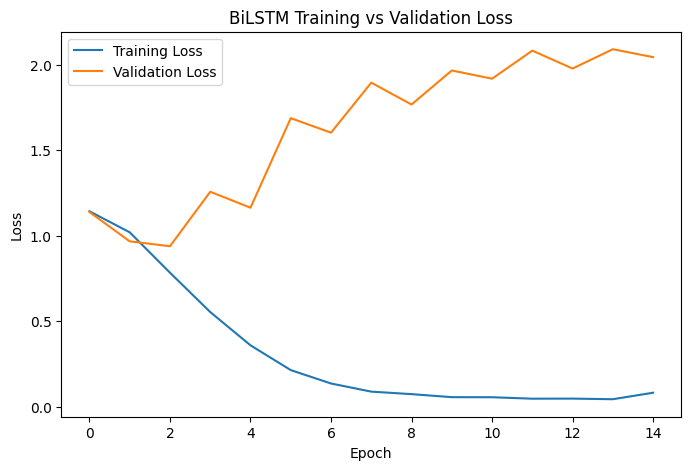

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Training vs Validation Accuracy")
plt.legend()
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Training vs Validation Loss")
plt.legend()
plt.show()

In [69]:
#evaluate the test
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test_encoded,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6680 - loss: 0.9761
Test Loss: 0.9761316776275635
Test Accuracy: 0.6679536700248718


              precision    recall  f1-score   support

    Negative       0.48      0.68      0.56       241
     Neutral       0.31      0.10      0.15       125
    Positive       0.79      0.77      0.78       670

    accuracy                           0.67      1036
   macro avg       0.52      0.52      0.50      1036
weighted avg       0.66      0.67      0.65      1036



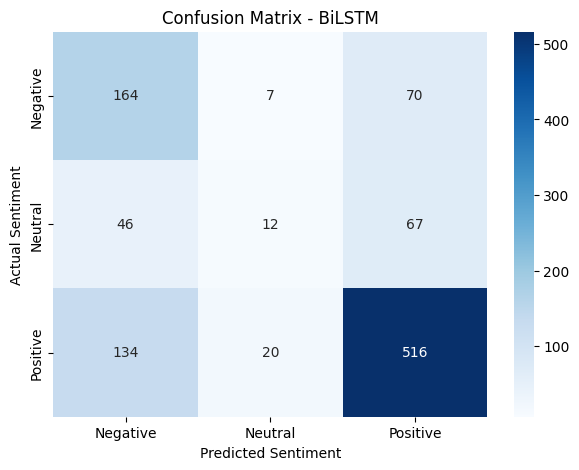

In [70]:

#classification report
from sklearn.metrics import classification_report

y_pred_prob = model.predict(
    X_test_pad,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print(
    classification_report(
        y_test_encoded,
        y_pred,
        labels=[0, 1, 2],
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        zero_division=0
    )
)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix - BiLSTM")
plt.show()

In [71]:
#check actual vs prediction
results = pd.DataFrame({
    "Actual": [
        ["Negative", "Neutral", "Positive"][x]
        for x in y_test_encoded
    ],
    "Predicted": [
        ["Negative", "Neutral", "Positive"][x]
        for x in y_pred
    ]
})

print(results.head(20))

      Actual Predicted
0   Positive  Negative
1   Positive  Positive
2   Negative  Negative
3   Positive  Positive
4   Positive  Negative
5   Negative  Positive
6   Positive  Negative
7   Positive  Positive
8   Positive  Positive
9   Negative  Negative
10  Negative  Positive
11  Positive  Positive
12   Neutral  Negative
13  Positive  Positive
14   Neutral  Negative
15   Neutral  Negative
16  Positive  Positive
17  Positive  Positive
18  Positive  Negative
19  Positive  Positive


In [74]:
new_review = """
This medication caused dizziness and made me feel very weak.
"""

cleaned = clean_text(new_review)

sequence = tokenizer.texts_to_sequences([cleaned])

padded = pad_sequences(
    sequence,
    maxlen=255,
    padding="post",
    truncating="post"
)

prediction = model.predict(
    padded,
    verbose=0
)

predicted_class = np.argmax(prediction[0])

sentiment_labels = [
    "Negative",
    "Neutral",
    "Positive"
]

predicted_sentiment = sentiment_labels[predicted_class]

confidence = prediction[0][predicted_class] * 100

print("Review:", new_review)
print("Predicted Sentiment:", predicted_sentiment)
print("Confidence:", round(confidence, 2), "%")

Review: 
This medication caused dizziness and made me feel very weak.

Predicted Sentiment: Positive
Confidence: 47.06 %
